In [3]:
import os

print(os.listdir("D:\\"))

['$RECYCLE.BIN', '2011 usain bolt.mp4', '20240610_111756.mp4', 'Ad Poster', 'alquizpuzzleteam.zip', 'Capacity develop', 'coop', 'DL Assignement', 'DL dataset', 'DPI', 'DumpStack.log.tmp', 'felicitation 2023.pptx', 'GTC9900', 'HealthBridge', 'Insath M', 'Islam', 'm', 'Mansoor', 'Mathematics Fever', 'Maths Singhala', 'MedInsight AI', 'Microsoft.Services.Store.winmd', 'Ministry', 'Mosque', 'Motivation', 'My projects', 'newoop', 'npm-cache', 'Online Class-1.pptx', 'Online Tutes-10 3rd term', 'Online Tutes-11 3rd term', 'OS (C) - Shortcut.lnk', 'Personal', 'Primary', 'Program Files', 'Province', 'Results analysis report.pptx', 'rtr24EE.tmp', 'System Volume Information', 'Temp', 'tmp', 'U demy', 'Vappa', 'WhatsApp Installer (2).exe', 'Wife']


In [4]:
import os

BASE_PATH = r"D:\DL Assignement"

print(os.listdir(BASE_PATH))

['aptos2019-blindness-detection', 'Deep-Learning-Assignment-Group-ID-5']


In [6]:
PROJECT_ROOT = os.path.join(
    BASE_PATH,
    "aptos2019-blindness-detection"
)


print(PROJECT_ROOT)

print(os.listdir(PROJECT_ROOT))

D:\DL Assignement\aptos2019-blindness-detection
['results', 'sample_submission.csv', 'test.csv', 'test_images', 'train.csv', 'train_images']


In [7]:
import pandas as pd


train_csv_path = os.path.join(
    PROJECT_ROOT,
    "train.csv"
)


df = pd.read_csv(train_csv_path)


print(df.head())


print("\nDataset shape:")
print(df.shape)

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Dataset shape:
(3662, 2)


In [8]:
class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]


df["label_name"] = df["diagnosis"].map(
    {
        0:"No_DR",
        1:"Mild",
        2:"Moderate",
        3:"Severe",
        4:"Proliferative_DR"
    }
)


df.head()

,id_code,diagnosis,label_name
0,000c1434d8d7,2,Moderate
1,001639a390f0,4,Proliferative_DR
2,0024cdab0c1e,1,Mild
3,002c21358ce6,0,No_DR
4,005b95c28852,0,No_DR


In [9]:
df["label_name"].value_counts()

label_name
No_DR               1805
Moderate             999
Mild                 370
Proliferative_DR     295
Severe               193
Name: count, dtype: int64

In [10]:
import os

IMAGE_FOLDER = os.path.join(
    PROJECT_ROOT,
    "train_images"
)


df["image_path"] = df["id_code"].apply(
    lambda x: os.path.join(
        IMAGE_FOLDER,
        x + ".png"
    )
)


df.head()

,id_code,diagnosis,label_name,image_path
0,000c1434d8d7,2,Moderate,D:\DL Assignement\aptos2019-blindness-detectio...
1,001639a390f0,4,Proliferative_DR,D:\DL Assignement\aptos2019-blindness-detectio...
2,0024cdab0c1e,1,Mild,D:\DL Assignement\aptos2019-blindness-detectio...
3,002c21358ce6,0,No_DR,D:\DL Assignement\aptos2019-blindness-detectio...
4,005b95c28852,0,No_DR,D:\DL Assignement\aptos2019-blindness-detectio...


In [11]:
from sklearn.model_selection import train_test_split


train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["diagnosis"],
    random_state=42
)


print("Training images:", len(train_df))
print("Validation images:", len(val_df))


print("\nTraining distribution:")
print(train_df["label_name"].value_counts())


print("\nValidation distribution:")
print(val_df["label_name"].value_counts())

Training images: 2929
Validation images: 733

Training distribution:
label_name
No_DR               1444
Moderate             799
Mild                 296
Proliferative_DR     236
Severe               154
Name: count, dtype: int64

Validation distribution:
label_name
No_DR               361
Moderate            200
Mild                 74
Proliferative_DR     59
Severe               39
Name: count, dtype: int64


In [12]:
import tensorflow as tf


IMG_SIZE = (224,224)
BATCH_SIZE = 32


def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.keras.applications.efficientnet.preprocess_input(
        image
    )

    return image, label



# Convert labels

train_paths = train_df["image_path"].values
train_labels = train_df["diagnosis"].values


val_paths = val_df["image_path"].values
val_labels = val_df["diagnosis"].values



# Create datasets

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_paths,
        train_labels
    )
)


val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_paths,
        val_labels
    )
)



train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)



train_dataset = train_dataset.shuffle(1000).batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)



val_dataset = val_dataset.batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)



print("Dataset created successfully")

Dataset created successfully


In [15]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


# Get training labels

y_train = train_df["diagnosis"].values


# Calculate balanced weights

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)


# Convert to dictionary

class_weights = dict(
    enumerate(class_weights_array)
)


print(class_weights)

{0: np.float64(0.4056786703601108), 1: np.float64(1.979054054054054), 2: np.float64(0.7331664580725907), 3: np.float64(3.803896103896104), 4: np.float64(2.4822033898305085)}


In [16]:
from model.efficientnetb0 import create_efficientnetb0


model = create_efficientnetb0()


model.summary()

ModuleNotFoundError: No module named 'model'

In [13]:
from tensorflow.keras.optimizers import Adam


model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)


print("Model compiled successfully")

NameError: name 'model' is not defined

In [19]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),


    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),


    ModelCheckpoint(
        "best_efficientnetb0.keras",
        monitor="val_accuracy",
        save_best_only=True
    )

]


print("Callbacks created")

Callbacks created


In [20]:
EPOCHS = 30


history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks

)

Epoch 1/30


d:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.5244 - loss: 1.3575 - val_accuracy: 0.6562 - val_loss: 0.9074 - learning_rate: 1.0000e-04
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6931 - loss: 1.0107 - val_accuracy: 0.7176 - val_loss: 0.7886 - learning_rate: 1.0000e-04
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.7419 - loss: 0.8743 - val_accuracy: 0.7340 - val_loss: 0.7171 - learning_rate: 1.0000e-04
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.7648 - loss: 0.7966 - val_accuracy: 0.7544 - val_loss: 0.6677 - learning_rate: 1.0000e-04
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.7945 - loss: 0.7154 - val_accuracy: 0.7531 - val_loss: 0.6660 - learning_rate: 1.0000e-04
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8071 - loss: 0.6706 - val_accuracy: 0.7626 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.8371 - loss: 0.6

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


# Get predictions

y_true = []
y_pred = []


for images, labels in val_dataset:

    predictions = model.predict(images)

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)



# Convert to numpy

y_true = np.array(y_true)
y_pred = np.array(y_pred)



# Class names

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Proliferative_DR",
    "Severe"
]



print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 962ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
                  precision    recall  f1-score   support

           No_DR       0.97      0.96      0.97       361
            Mild       0.50    

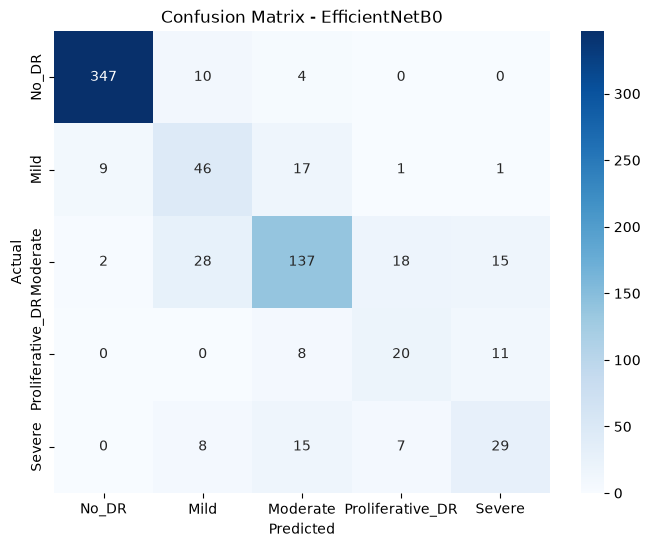

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(8,6))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")


plt.show()

In [17]:
import os

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "results"
)

# Create results folder if not exists
os.makedirs(MODEL_DIR, exist_ok=True)


MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_efficientnetb0.keras"
)


# Save trained model
model.save(MODEL_PATH)


print("Model saved successfully!")
print(MODEL_PATH)

NameError: name 'model' is not defined

In [18]:
import os

print(os.path.exists(MODEL_PATH))

True


In [19]:
import os

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "best_efficientnetb0.keras"
)

print(MODEL_PATH)
print(os.path.exists(MODEL_PATH))

D:\DL Assignement\aptos2019-blindness-detection\results\best_efficientnetb0.keras
True


In [22]:
import os
import datetime

print(
    datetime.datetime.fromtimestamp(
        os.path.getmtime(MODEL_PATH)
    )
)

2026-09-27 23:41:36.698234


In [2]:
import os
import tensorflow as tf

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "best_efficientnetb0.keras"
)

print("Model path:")
print(MODEL_PATH)

print("\nModel exists:", os.path.exists(MODEL_PATH))

model = tf.keras.models.load_model(MODEL_PATH)

print("\nModel loaded successfully!")
model.summary()

NameError: name 'PROJECT_ROOT' is not defined

In [1]:
# Find convolutional layers inside EfficientNetB0

for i, layer in enumerate(model.layers[0].layers):
    if "conv" in layer.name.lower():
        print(i, layer.name, layer.__class__.__name__)

NameError: name 'model' is not defined

In [23]:
import os
import tensorflow as tf

# ==========================================
# PROJECT PATH
# ==========================================

PROJECT_ROOT = r"D:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\EfficientNetB0"

print("Project root:")
print(PROJECT_ROOT)

print("\nProject exists:")
print(os.path.exists(PROJECT_ROOT))

print("\nProject contents:")
print(os.listdir(PROJECT_ROOT))

Project root:
D:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\EfficientNetB0

Project exists:
True

Project contents:
['model', 'notebook', 'preprocessing', 'results']


In [24]:
# ==========================================
# SAVED MODEL PATH
# ==========================================

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "best_efficientnetb0.keras"
)

print("Model path:")
print(MODEL_PATH)

print("\nModel exists:")
print(os.path.exists(MODEL_PATH))

Model path:
D:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\EfficientNetB0\results\best_efficientnetb0.keras

Model exists:
True


In [25]:
# ==========================================
# LOAD TRAINED MODEL
# ==========================================

model = tf.keras.models.load_model(MODEL_PATH)

print("==========================================")
print("Trained model loaded successfully!")
print("==========================================")

model.summary()

Trained model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,770,708 (25.83 MB)

 Trainable params: 1,357,365 (5.18 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

 Optimizer params: 2,714,732 (10.36 MB)

In [26]:
# ==========================================
# MODEL VERIFICATION
# ==========================================

print("Number of model layers:", len(model.layers))

print("\nInput shape:")
print(model.input_shape)

print("\nOutput shape:")
print(model.output_shape)

Number of model layers: 4

Input shape:
(None, 224, 224, 3)

Output shape:
(None, 5)


In [27]:
# ==========================================
# GET EFFICIENTNETB0 BASE MODEL
# ==========================================

base_model = model.layers[0]

print("Base model:")
print(base_model.name)

print("\nBase model type:")
print(type(base_model))

print("\nNumber of layers:")
print(len(base_model.layers))

Base model:
efficientnetb0

Base model type:
<class 'keras.src.models.functional.Functional'>

Number of layers:
238


In [28]:
# ==========================================
# FIND CONVOLUTIONAL LAYERS
# ==========================================

print("Convolutional layers inside EfficientNetB0:")
print("=" * 60)

for i, layer in enumerate(base_model.layers):

    if "conv" in layer.name.lower():

        print(
            i,
            "|",
            layer.name,
            "|",
            layer.__class__.__name__
        )

Convolutional layers inside EfficientNetB0:
4 | stem_conv_pad | ZeroPadding2D
5 | stem_conv | Conv2D
8 | block1a_dwconv | DepthwiseConv2D
16 | block1a_project_conv | Conv2D
18 | block2a_expand_conv | Conv2D
21 | block2a_dwconv_pad | ZeroPadding2D
22 | block2a_dwconv | DepthwiseConv2D
30 | block2a_project_conv | Conv2D
32 | block2b_expand_conv | Conv2D
35 | block2b_dwconv | DepthwiseConv2D
43 | block2b_project_conv | Conv2D
47 | block3a_expand_conv | Conv2D
50 | block3a_dwconv_pad | ZeroPadding2D
51 | block3a_dwconv | DepthwiseConv2D
59 | block3a_project_conv | Conv2D
61 | block3b_expand_conv | Conv2D
64 | block3b_dwconv | DepthwiseConv2D
72 | block3b_project_conv | Conv2D
76 | block4a_expand_conv | Conv2D
79 | block4a_dwconv_pad | ZeroPadding2D
80 | block4a_dwconv | DepthwiseConv2D
88 | block4a_project_conv | Conv2D
90 | block4b_expand_conv | Conv2D
93 | block4b_dwconv | DepthwiseConv2D
101 | block4b_project_conv | Conv2D
105 | block4c_expand_conv | Conv2D
108 | block4c_dwconv | Depthw

In [29]:
# ==========================================
# FIND LAST CONVOLUTIONAL LAYER
# ==========================================

last_conv_layer = None

for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Last Conv2D layer:")
print(last_conv_layer.name)

print("\nLayer type:")
print(last_conv_layer.__class__.__name__)

Last Conv2D layer:
top_conv

Layer type:
Conv2D


In [36]:
# ==========================================
# GRAD-CAM FOR NESTED EFFICIENTNETB0
# ==========================================

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer):

    # Build the classifier part after EfficientNetB0
    classifier_input = tf.keras.Input(
        shape=base_model.output.shape[1:]
    )

    x = classifier_input

    # Apply layers after EfficientNetB0
    for layer in model.layers[1:]:
        x = layer(x)

    classifier_model = tf.keras.Model(
        classifier_input,
        x
    )

    # Feature extractor
    feature_model = tf.keras.Model(
        base_model.input,
        last_conv_layer.output
    )

    with tf.GradientTape() as tape:

        # Get convolutional feature maps
        conv_outputs = feature_model(img_array)

        # Make sure gradients are tracked
        tape.watch(conv_outputs)

        # Continue through classifier
        pooled = model.layers[1](conv_outputs)

        x = pooled

        for layer in model.layers[2:]:
            x = layer(x)

        predictions = x

        predicted_class = tf.argmax(predictions[0])

        class_score = predictions[:, predicted_class]

    # Calculate gradients
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = heatmap / (
        max_value + tf.keras.backend.epsilon()
    )

    return (
        heatmap.numpy(),
        int(predicted_class.numpy())
    )

In [31]:
print("Grad-CAM function created successfully!")

Grad-CAM function created successfully!


In [32]:
# ==========================================
# TEST GRAD-CAM ON ONE REAL FUNDUS IMAGE
# ==========================================

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Get one image from validation dataframe
sample_path = val_df.iloc[0]["image_path"]
true_label = val_df.iloc[0]["label_name"]

print("Image path:")
print(sample_path)

print("\nTrue label:")
print(true_label)

Image path:
D:\DL Assignement\aptos2019-blindness-detection\train_images\6fe67fd7f5d1.png

True label:
No_DR


In [33]:
# ==========================================
# PREPROCESS IMAGE
# ==========================================

IMG_SIZE = (224, 224)

img = Image.open(sample_path).convert("RGB")
original_img = img.copy()

img = img.resize(IMG_SIZE)

img_array = np.array(img, dtype=np.float32)

# EfficientNet preprocessing
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

print("Input shape:", img_array.shape)

Input shape: (1, 224, 224, 3)


In [34]:
# ==========================================
# PREDICTION + GRAD-CAM
# ==========================================

predictions = model.predict(img_array, verbose=0)

predicted_class = np.argmax(predictions[0])
confidence = predictions[0][predicted_class]

heatmap, gradcam_class = make_gradcam_heatmap(
    img_array,
    model,
    base_model,
    last_conv_layer
)

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]

print("True label:", true_label)
print("Predicted class:", class_names[predicted_class])
print("Confidence:", round(float(confidence), 4))
print("Heatmap shape:", heatmap.shape)

AttributeError: The layer sequential has never been called and thus has no defined output.

In [37]:
print("New Grad-CAM function loaded successfully!")

New Grad-CAM function loaded successfully!


In [38]:
predictions = model.predict(img_array, verbose=0)

predicted_class = np.argmax(predictions[0])
confidence = predictions[0][predicted_class]

heatmap, gradcam_class = make_gradcam_heatmap(
    img_array,
    model,
    base_model,
    last_conv_layer
)

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]

print("True label:", true_label)
print("Predicted class:", class_names[predicted_class])
print("Confidence:", round(float(confidence), 4))
print("Heatmap shape:", heatmap.shape)

True label: No_DR
Predicted class: No_DR
Confidence: 0.9976
Heatmap shape: (7, 7)


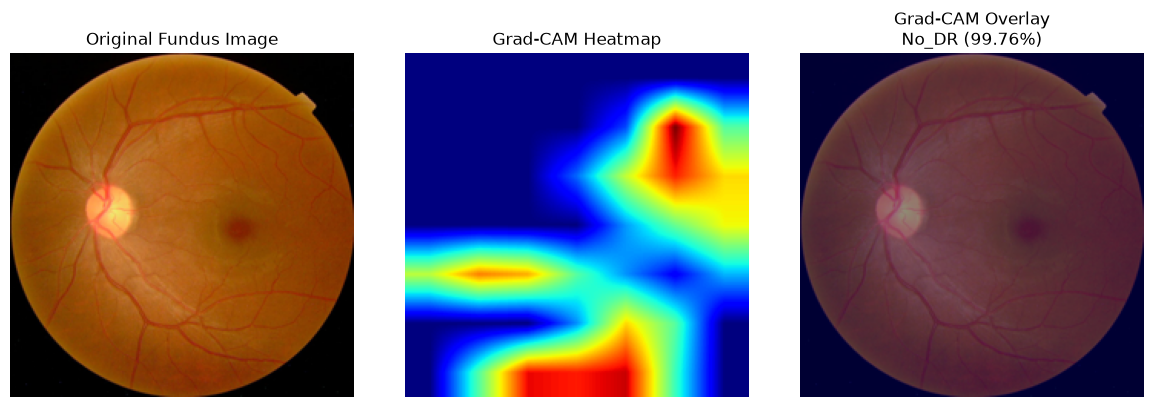

In [39]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Convert heatmap to 224x224
heatmap_resized = cv2.resize(
    heatmap,
    (224, 224)
)

# Convert to RGB image
original_image = img_array[0].copy()

# Normalize image for display
original_image = original_image - original_image.min()
original_image = original_image / original_image.max()

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR → RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay Grad-CAM
overlay = (
    0.6 * original_image * 255
    + 0.4 * heatmap_color
)

overlay = np.clip(
    overlay,
    0,
    255
).astype(np.uint8)

# Display
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Fundus Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\n{class_names[predicted_class]} ({confidence:.2%})"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# SEVERITY-AWARE GRAD-CAM
# Direct implementation for loaded EfficientNetB0 model
# ============================================================

import tensorflow as tf
import numpy as np
import cv2

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]


def generate_class_gradcam(
    image,
    model,
    base_model,
    class_index
):
    """
    Generate Grad-CAM for one specific DR severity class.
    """

    with tf.GradientTape() as tape:

        # Get EfficientNetB0 convolutional feature maps
        conv_outputs = base_model(
            image,
            training=False
        )

        # Pass feature maps through the classification head
        x = conv_outputs

        for layer in model.layers[1:]:
            x = layer(
                x,
                training=False
            )

        predictions = x

        # Score for selected class
        class_score = predictions[:, class_index]

    # Gradient of selected class score
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_output = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]

    # Remove final dimension
    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = heatmap / (
        max_value + tf.keras.backend.epsilon()
    )

    # Convert to NumPy
    heatmap = heatmap.numpy()

    # Resize to input image size
    heatmap = cv2.resize(
        heatmap,
        (224, 224)
    )

    return heatmap, predictions.numpy()[0]


print("Grad-CAM function created successfully!")

Grad-CAM function created successfully!


In [44]:
# ============================================================
# TEST GRAD-CAM FOR PREDICTED CLASS
# ============================================================

heatmap, probabilities = generate_class_gradcam(
    img_array,
    model,
    base_model,
    predicted_class
)

print("Predicted class:", class_names[predicted_class])
print("Confidence:", round(float(probabilities[predicted_class]), 4))
print("Heatmap shape:", heatmap.shape)
print("Probability vector:", probabilities)

Predicted class: No DR
Confidence: 0.9976
Heatmap shape: (224, 224)
Probability vector: [9.9761558e-01 1.4019193e-03 4.8241578e-04 2.1062937e-04 2.8955849e-04]


In [45]:
# ============================================================
# SEVERITY-AWARE 5-CLASS GRAD-CAM
# ============================================================

severity_heatmaps = []

for class_index in range(5):

    heatmap, probabilities = generate_class_gradcam(
        img_array,
        model,
        base_model,
        class_index
    )

    severity_heatmaps.append(heatmap)

    print(
        f"{class_index}: {class_names[class_index]} "
        f"-> heatmap shape: {heatmap.shape}"
    )

print("\nAll 5 Grad-CAM heatmaps generated successfully!")

0: No DR -> heatmap shape: (224, 224)
1: Mild -> heatmap shape: (224, 224)
2: Moderate -> heatmap shape: (224, 224)
3: Severe -> heatmap shape: (224, 224)
4: Proliferative DR -> heatmap shape: (224, 224)

All 5 Grad-CAM heatmaps generated successfully!


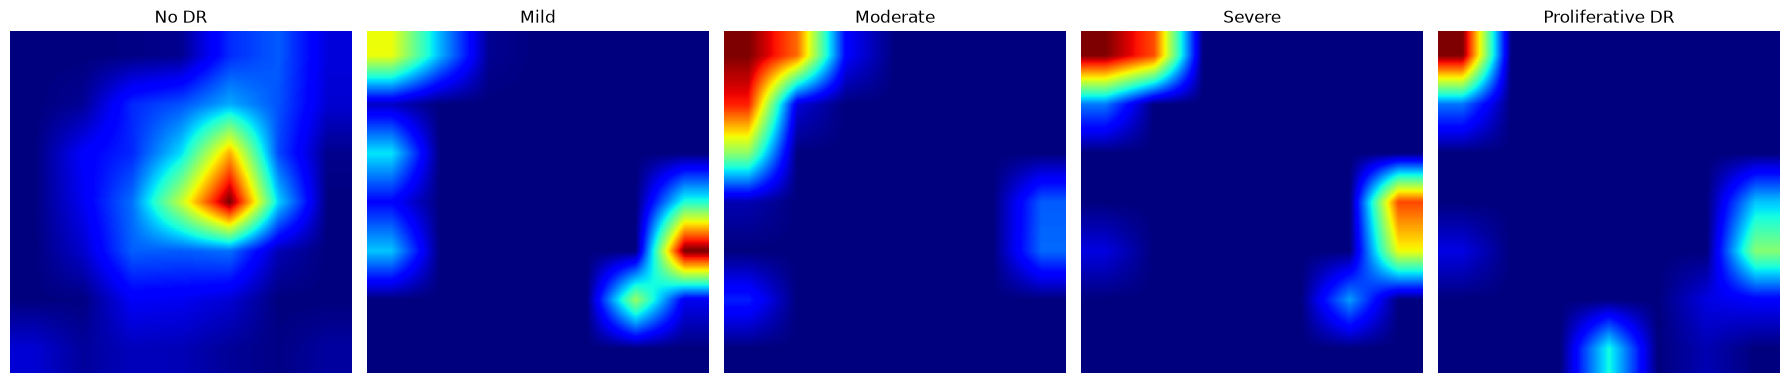

In [46]:
# ============================================================
# DISPLAY 5 SEVERITY-AWARE GRAD-CAM HEATMAPS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(severity_heatmaps[i], cmap="jet")
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# SEVERITY-AWARE GRAD-CAM OVERLAYS
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert input image to display format
original_image = img_array[0].copy()

# If image values are 0-1, convert to 0-255
if original_image.max() <= 1.0:
    original_image = (original_image * 255).astype(np.uint8)
else:
    original_image = original_image.astype(np.uint8)

# Store overlay images
severity_overlays = []

for i in range(5):

    # Convert heatmap to 0-255
    heatmap_uint8 = np.uint8(255 * severity_heatmaps[i])

    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(
        heatmap_uint8,
        (original_image.shape[1], original_image.shape[0])
    )

    # Apply colour map
    heatmap_color = cv2.applyColorMap(
        heatmap_resized,
        cv2.COLORMAP_JET
    )

    # Convert RGB image to BGR
    original_bgr = cv2.cvtColor(
        original_image,
        cv2.COLOR_RGB2BGR
    )

    # Blend original image + heatmap
    overlay = cv2.addWeighted(
        original_bgr,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Convert back to RGB for matplotlib
    overlay = cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )

    severity_overlays.append(overlay)

print("All 5 Grad-CAM overlays generated successfully!")

All 5 Grad-CAM overlays generated successfully!


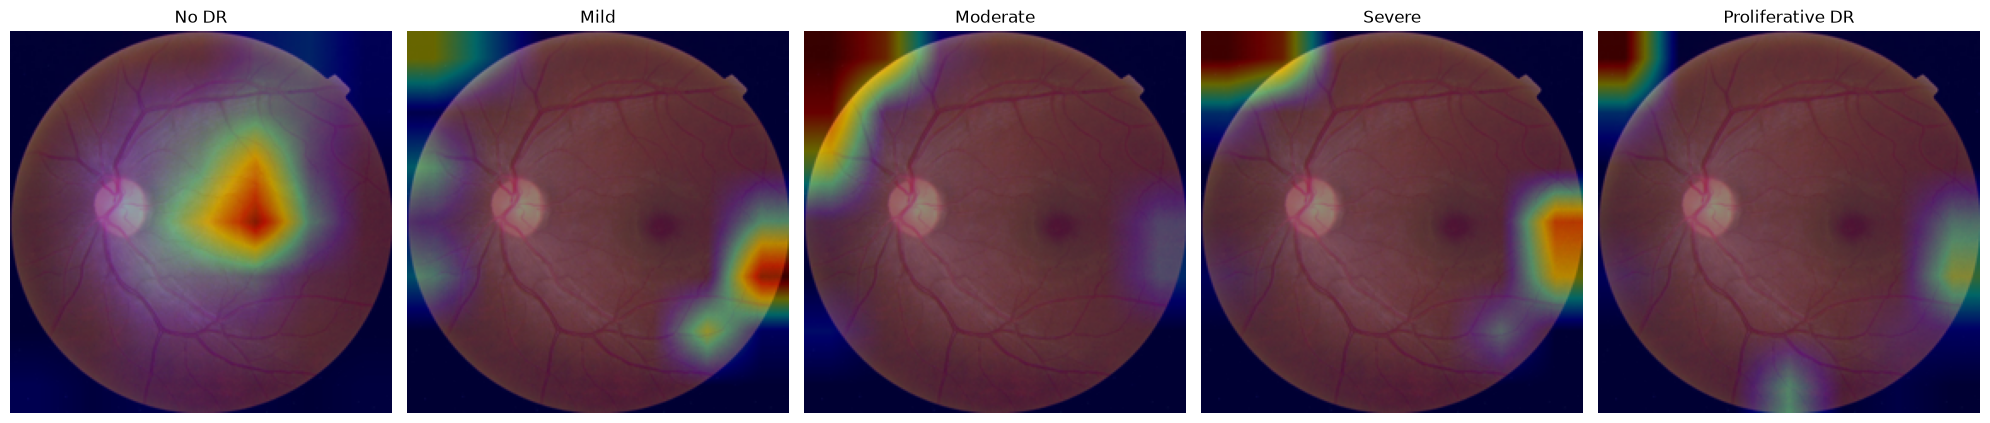

In [48]:
# ============================================================
# DISPLAY SEVERITY-AWARE GRAD-CAM OVERLAYS
# ============================================================

plt.figure(figsize=(20, 5))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(severity_overlays[i])
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# SAVE SEVERITY-AWARE GRAD-CAM RESULTS
# ============================================================

import os
import cv2

GRADCAM_DIR = os.path.join(PROJECT_ROOT, "results", "gradcam")

os.makedirs(GRADCAM_DIR, exist_ok=True)

for i in range(5):

    class_name = class_names[i].replace(" ", "_")

    # Save heatmap
    heatmap_path = os.path.join(
        GRADCAM_DIR,
        f"gradcam_{i}_{class_name}_heatmap.png"
    )

    heatmap_uint8 = np.uint8(
        255 * severity_heatmaps[i]
    )

    cv2.imwrite(
        heatmap_path,
        heatmap_uint8
    )

    # Save overlay
    overlay_path = os.path.join(
        GRADCAM_DIR,
        f"gradcam_{i}_{class_name}_overlay.png"
    )

    overlay_bgr = cv2.cvtColor(
        severity_overlays[i],
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(
        overlay_path,
        overlay_bgr
    )

    print(f"Saved: {class_name}")

print("\nAll Grad-CAM results saved successfully!")
print("Folder:", GRADCAM_DIR)

Saved: No_DR
Saved: Mild
Saved: Moderate
Saved: Severe
Saved: Proliferative_DR

All Grad-CAM results saved successfully!
Folder: D:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\EfficientNetB0\results\gradcam


In [50]:
# ============================================================
# VERIFY SAVED GRAD-CAM FILES
# ============================================================

print("\nSaved files:")

for file in sorted(os.listdir(GRADCAM_DIR)):
    print(file)


Saved files:
gradcam_0_No_DR_heatmap.png
gradcam_0_No_DR_overlay.png
gradcam_1_Mild_heatmap.png
gradcam_1_Mild_overlay.png
gradcam_2_Moderate_heatmap.png
gradcam_2_Moderate_overlay.png
gradcam_3_Severe_heatmap.png
gradcam_3_Severe_overlay.png
gradcam_4_Proliferative_DR_heatmap.png
gradcam_4_Proliferative_DR_overlay.png


In [51]:
# ============================================================
# SAVE SEVERITY-AWARE GRAD-CAM RESULTS
# ============================================================

import os
import cv2

GRADCAM_DIR = os.path.join(PROJECT_ROOT, "results", "gradcam")

os.makedirs(GRADCAM_DIR, exist_ok=True)

for i in range(5):

    class_name = class_names[i].replace(" ", "_")

    # Save heatmap
    heatmap_path = os.path.join(
        GRADCAM_DIR,
        f"gradcam_{i}_{class_name}_heatmap.png"
    )

    heatmap_uint8 = np.uint8(
        255 * severity_heatmaps[i]
    )

    cv2.imwrite(
        heatmap_path,
        heatmap_uint8
    )

    # Save overlay
    overlay_path = os.path.join(
        GRADCAM_DIR,
        f"gradcam_{i}_{class_name}_overlay.png"
    )

    overlay_bgr = cv2.cvtColor(
        severity_overlays[i],
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(
        overlay_path,
        overlay_bgr
    )

    print(f"Saved: {class_name}")

print("\nAll Grad-CAM results saved successfully!")
print("Folder:", GRADCAM_DIR)

Saved: No_DR
Saved: Mild
Saved: Moderate
Saved: Severe
Saved: Proliferative_DR

All Grad-CAM results saved successfully!
Folder: D:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\EfficientNetB0\results\gradcam


In [52]:
# ============================================================
# VERIFY SAVED GRAD-CAM FILES
# ============================================================

print("\nSaved files:")

for file in sorted(os.listdir(GRADCAM_DIR)):
    print(file)


Saved files:
gradcam_0_No_DR_heatmap.png
gradcam_0_No_DR_overlay.png
gradcam_1_Mild_heatmap.png
gradcam_1_Mild_overlay.png
gradcam_2_Moderate_heatmap.png
gradcam_2_Moderate_overlay.png
gradcam_3_Severe_heatmap.png
gradcam_3_Severe_overlay.png
gradcam_4_Proliferative_DR_heatmap.png
gradcam_4_Proliferative_DR_overlay.png


In [53]:
# ============================================================
# FINAL INFERENCE FUNCTION
# ============================================================

def predict_with_gradcam(img_array):
    """
    Run EfficientNetB0 prediction and generate
    Grad-CAM heatmaps for all 5 DR severity classes.
    """

    # -----------------------------
    # 1. Prediction
    # -----------------------------
    predictions = model.predict(
        img_array,
        verbose=0
    )

    probabilities = predictions[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[predicted_class]
    )

    # -----------------------------
    # 2. Generate 5 Grad-CAMs
    # -----------------------------
    heatmaps = []

    for class_index in range(5):

        heatmap, _ = generate_class_gradcam(
            img_array,
            model,
            base_model,
            class_index
        )

        heatmaps.append(heatmap)

    # -----------------------------
    # 3. Result
    # -----------------------------
    result = {
        "predicted_class": predicted_class,
        "predicted_label": class_names[predicted_class],
        "confidence": confidence,
        "probabilities": probabilities.tolist(),
        "heatmaps": heatmaps
    }

    return result


print("Final inference function created successfully!")

Final inference function created successfully!


In [54]:
# ============================================================
# TEST COMPLETE INFERENCE PIPELINE
# ============================================================

result = predict_with_gradcam(img_array)

print("========================================")
print("DIABETIC RETINOPATHY AI RESULT")
print("========================================")

print("Predicted class:")
print(result["predicted_class"])

print("\nPredicted severity:")
print(result["predicted_label"])

print("\nConfidence:")
print(round(result["confidence"], 4))

print("\nClass probabilities:")

for i, probability in enumerate(result["probabilities"]):

    print(
        f"{class_names[i]:20s}: "
        f"{probability:.4f}"
    )

print("\nNumber of Grad-CAM heatmaps:")
print(len(result["heatmaps"]))

print("\nHeatmap shapes:")

for i, heatmap in enumerate(result["heatmaps"]):

    print(
        f"{class_names[i]:20s}: "
        f"{heatmap.shape}"
    )

DIABETIC RETINOPATHY AI RESULT
Predicted class:
0

Predicted severity:
No DR

Confidence:
0.9976

Class probabilities:
No DR               : 0.9976
Mild                : 0.0014
Moderate            : 0.0005
Severe              : 0.0002
Proliferative DR    : 0.0003

Number of Grad-CAM heatmaps:
5

Heatmap shapes:
No DR               : (224, 224)
Mild                : (224, 224)
Moderate            : (224, 224)
Severe              : (224, 224)
Proliferative DR    : (224, 224)


In [55]:
# ============================================================
# CONVERT GRAD-CAM HEATMAP TO BASE64 PNG
# ============================================================

import base64
from io import BytesIO
from PIL import Image


def heatmap_to_base64(heatmap):
    """
    Convert a Grad-CAM heatmap (0-1 NumPy array)
    into a Base64 encoded PNG.
    """

    # Convert 0-1 to 0-255
    heatmap_uint8 = np.uint8(
        np.clip(heatmap, 0, 1) * 255
    )

    # Convert NumPy array to PIL image
    image = Image.fromarray(
        heatmap_uint8,
        mode="L"
    )

    # Store image in memory
    buffer = BytesIO()

    image.save(
        buffer,
        format="PNG"
    )

    # Convert to Base64
    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    return encoded


print("Heatmap Base64 conversion function created successfully!")

Heatmap Base64 conversion function created successfully!


In [56]:
# ============================================================
# CONVERT ALL 5 GRAD-CAM HEATMAPS TO BASE64
# ============================================================

heatmap_base64 = []

for i, heatmap in enumerate(result["heatmaps"]):

    encoded_heatmap = heatmap_to_base64(
        heatmap
    )

    heatmap_base64.append(
        encoded_heatmap
    )

    print(
        f"{class_names[i]} -> "
        f"{len(encoded_heatmap)} Base64 characters"
    )

print("\nAll 5 heatmaps converted successfully!")

No DR -> 8060 Base64 characters
Mild -> 4888 Base64 characters
Moderate -> 3912 Base64 characters
Severe -> 3972 Base64 characters
Proliferative DR -> 4212 Base64 characters

All 5 heatmaps converted successfully!


In [57]:
# ============================================================
# FINAL API-READY RESPONSE
# ============================================================

api_result = {
    "predicted_class": result["predicted_class"],
    "predicted_severity": result["predicted_label"],
    "confidence": result["confidence"],

    "probabilities": {
        class_names[i]: float(
            result["probabilities"][i]
        )
        for i in range(5)
    },

    "gradcam": {
        class_names[i]: heatmap_base64[i]
        for i in range(5)
    }
}

print("API response created successfully!")
print("\nPrediction:")
print(api_result["predicted_severity"])

print("\nConfidence:")
print(round(api_result["confidence"], 4))

print("\nProbability classes:")
for class_name, probability in api_result["probabilities"].items():
    print(
        f"{class_name}: {probability:.4f}"
    )

print("\nGrad-CAM classes:")
for class_name in api_result["gradcam"]:
    print(
        f"{class_name}: Base64 image"
    )

API response created successfully!

Prediction:
No DR

Confidence:
0.9976

Probability classes:
No DR: 0.9976
Mild: 0.0014
Moderate: 0.0005
Severe: 0.0002
Proliferative DR: 0.0003

Grad-CAM classes:
No DR: Base64 image
Mild: Base64 image
Moderate: Base64 image
Severe: Base64 image
Proliferative DR: Base64 image


In [58]:
# ============================================================
# SAVE MODEL CONFIGURATION
# ============================================================

import json
import os

MODEL_CONFIG = {
    "model_path": MODEL_PATH,
    "input_size": [224, 224],
    "num_classes": 5,
    "class_names": [
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative DR"
    ],
    "gradcam_layer": last_conv_layer.name
}

CONFIG_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "model_config.json"
)

with open(CONFIG_PATH, "w") as f:
    json.dump(
        MODEL_CONFIG,
        f,
        indent=4
    )

print("Model configuration saved successfully!")
print(CONFIG_PATH)

Model configuration saved successfully!
D:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\EfficientNetB0\results\model_config.json


In [59]:
# ============================================================
# VERIFY MODEL CONFIGURATION
# ============================================================

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

print(json.dumps(config, indent=4))

{
    "model_path": "D:\\DL Assignement\\Deep-Learning-Assignment-Group-ID-5\\EfficientNetB0\\results\\best_efficientnetb0.keras",
    "input_size": [
        224,
        224
    ],
    "num_classes": 5,
    "class_names": [
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative DR"
    ],
    "gradcam_layer": "top_conv"
}
